In [58]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [60]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [61]:
wfid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "withering", 0)
wsatgen500 = wfid500[wfid500["logMvir"] > 12.5]
wsatgen500 = wsatgen500.sort_values("logMvir")

wsmdnorm = jsm_simload.CorrNorm_simulations(wsatgen500, dataset_title="SatGen", data_color="palevioletred")

In [62]:
rfid500 = jsm_ancillary.load_massspec("../../data/Nparticle/N500/", "Rvir", 0)
rsatgen500 = rfid500[rfid500["logMvir"] > 12.5]
rsatgen500 = rsatgen500.sort_values("logMvir")

rsmdnorm = jsm_simload.CorrNorm_simulations(rsatgen500, dataset_title="SatGen", data_color="palevioletred")

In [63]:
f_rvir = 10**rsatgen500["logNsub"] / 10**wsatgen500["logNsub"]

In [64]:
wsatgen500

,logMvir,log1pz50,logc,logNsub,logfsub,logMMs,delta_log1pz50,delta_logc,delta_logNsub,delta_logMMs
1999,12.6,0.098967,1.038838,-inf,-inf,-1.850191,-0.209099,0.008501,-inf,-0.419254
1341,12.6,0.180972,0.962576,-inf,-inf,-1.849737,-0.127095,-0.067761,-inf,-0.418800
1340,12.6,0.216833,0.907274,-inf,-inf,-1.732602,-0.091234,-0.123063,-inf,-0.301665
1339,12.6,0.302382,1.056286,0.000000,-1.697288,-1.697288,-0.005685,0.025949,-0.094251,-0.266351
1338,12.6,0.305693,1.029549,-inf,-inf,-1.789458,-0.002374,-0.000788,-inf,-0.358521
...,...,...,...,...,...,...,...,...,...,...
5661,14.0,0.255878,0.977702,1.612784,-0.699330,-1.027653,0.034602,0.148472,0.022605,0.316208
5660,14.0,0.203701,0.929781,1.531479,-0.614624,-0.938791,-0.017575,0.100552,-0.058700,0.405070
5659,14.0,0.103226,0.663189,1.518514,-0.722377,-1.284481,-0.118050,-0.166041,-0.071665,0.059380
5672,14.0,0.166396,0.626839,1.531479,-0.727498,-1.501734,-0.054880,-0.202390,-0.058700,-0.157873


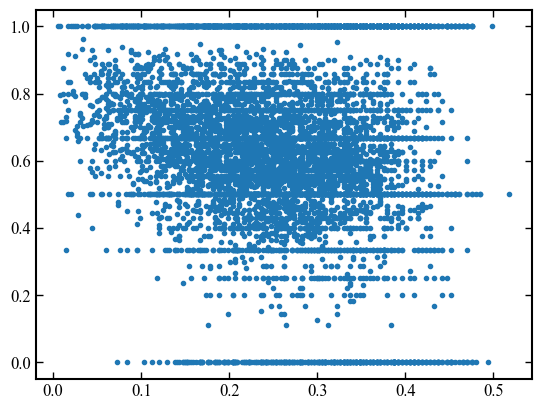

In [66]:
plt.scatter(wsatgen500["log1pz50"], f_rvir, marker=".")

In [30]:
wsmdnorm.logNsub_med

array([0.        , 0.30103   , 0.60205999, 0.77815125, 0.95424251,
       1.17609126, 1.38021124, 1.5797836 ,        nan])

<ErrorbarContainer object of 3 artists>

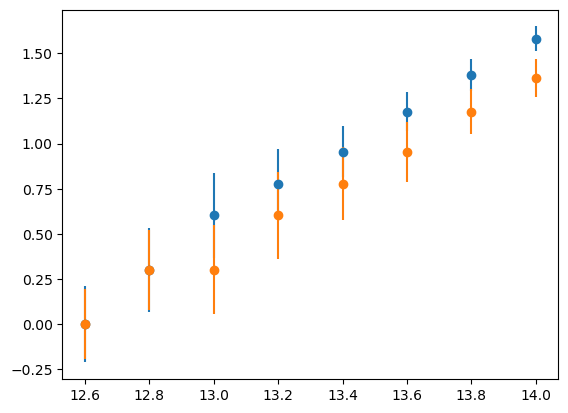

In [ ]:
plt.errorbar(wsmdnorm.logMvir_bincenters, wsmdnorm.logNsub_med, yerr=wsmdnorm.logNsub_std, fmt="o")
plt.errorbar(rsmdnorm.logMvir_bincenters, rsmdnorm.logNsub_med, yerr=rsmdnorm.logNsub_std, fmt="o")

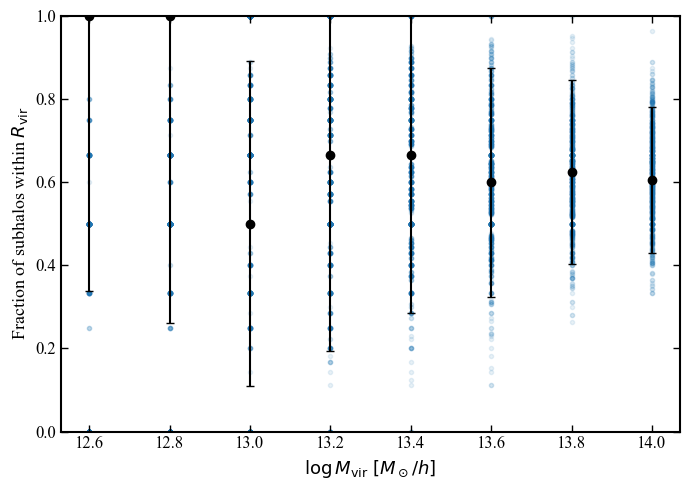

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Convert medians from log to linear
Nsubw = 10**wsmdnorm.logNsub_med
Nsub2 = 10**rsmdnorm.logNsub_med

# Fraction of subhalos inside Rvir
f = Nsub2 / Nsubw  # should span 0 to 1

# Propagate uncertainties
# σ_N = N * ln(10) * σ_logN  (from log->linear conversion)
# σ_f/f = sqrt( (σ_Nsub2/Nsub2)^2 + (σ_Nsubw/Nsubw)^2 )
#        = ln(10) * sqrt( σ_logNsub2^2 + σ_logNsubw^2 )
sigma_f = f * np.log(10) * np.sqrt(rsmdnorm.logNsub_std**2 + wsmdnorm.logNsub_std**2)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(wsmdnorm.logMvir_bincenters,f,yerr=sigma_f,fmt="o",c="k", capsize=3)

ax.scatter(wsatgen500["logMvir"], f_rvir, alpha=0.1, marker=".")
ax.set_ylim(0, 1)

ax.set_xlabel(r"$\log M_\mathrm{vir}\ [M_\odot/h]$", fontsize=13)
ax.set_ylabel("Fraction of subhalos within $R_\mathrm{vir}$", fontsize=13)

plt.tight_layout()
plt.show()